In [1]:
import numpy as np
from scipy.ndimage import gaussian_filter, binary_erosion, binary_dilation
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from scipy import ndimage
from typing import Tuple, Dict, Union
import warnings
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [2]:
def auto_select_aif(volume):
    """Automatically select arterial input function based on curve characteristics"""
    n_timepoints = volume.shape[0]
    
    # Reshape to 2D array (time, voxels)
    curves = volume.reshape(n_timepoints, -1)
    
    # Extract curve features
    curve_features = np.zeros((curves.shape[1], 3))
    
    # First derivative to find slopes
    derivatives = np.diff(curves, axis=0)
    
    # Feature 1: Maximum value
    curve_features[:, 0] = np.max(curves, axis=0)
    
    # Feature 2: Time to peak
    curve_features[:, 1] = np.argmax(curves, axis=0)
    
    # Feature 3: Maximum upslope
    curve_features[:, 2] = np.max(derivatives, axis=0)
    
    # Normalize features
    scaler = StandardScaler()
    curve_features_norm = scaler.fit_transform(curve_features)
    
    # Filter out low-intensity voxels
    intensity_threshold = np.percentile(curve_features[:, 0], 75)
    valid_voxels = curve_features[:, 0] > intensity_threshold
    filtered_features = curve_features_norm[valid_voxels]
    filtered_indices = np.where(valid_voxels)[0]
    
    if len(filtered_indices) < 10:  # If too few voxels remain
        # Use top 1% of voxels by intensity
        top_indices = np.argsort(curve_features[:, 0])[-int(curves.shape[1] * 0.01):]
        return np.mean(curves[:, top_indices], axis=1)
    
    # Perform clustering
    kmeans = KMeans(n_clusters=5, random_state=42)
    clusters = kmeans.fit_predict(filtered_features)
    
    # For each cluster, calculate metrics that characterize a good AIF
    # (early arrival, high peak, steep upslope)
    cluster_scores = []
    for i in range(5):
        cluster_mask = clusters == i
        if np.sum(cluster_mask) == 0:
            cluster_scores.append(-np.inf)
            continue
            
        cluster_indices = filtered_indices[cluster_mask]
        cluster_curves = curves[:, cluster_indices]
        
        # Calculate average curve
        avg_curve = np.mean(cluster_curves, axis=1)
        
        # Metrics
        peak_val = np.max(avg_curve)
        peak_time = np.argmax(avg_curve)
        max_slope = np.max(np.diff(avg_curve))
        
        # Early arrival (lower is better) + high peak + steep upslope
        score = -peak_time/n_timepoints + peak_val/np.max(curves) + max_slope/np.max(derivatives)
        cluster_scores.append(score)
    
    # Select best cluster
    best_cluster = np.argmax(cluster_scores)
    best_indices = filtered_indices[clusters == best_cluster]
    
    # Return mean curve of the best cluster
    return np.mean(curves[:, best_indices], axis=1)

In [3]:
scan = np.load('Experiments/ISLES_PreprocessedData/case_47_4.npy')

In [4]:
aif = auto_select_aif(scan)

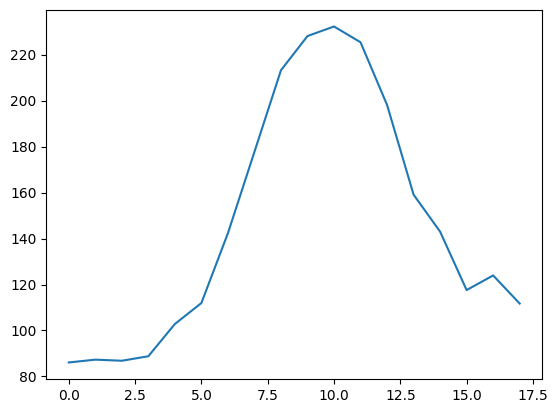

In [5]:
plt.plot(aif)

In [27]:


def calculate_perfusion_parameters(
    ct_4d: np.ndarray,
    temporal_resolution: float = 1.0,
    baseline_timepoints: int = 2
) -> Dict[str, np.ndarray]:
    """
    Calculate perfusion parameters using maximum slope method from 4D CT perfusion data.
    
    Args:
        ct_4d: 4D numpy array of shape (T, D, H, W) containing CT perfusion data
        temporal_resolution: Time between volumes in seconds
        baseline_timepoints: Number of timepoints to use for baseline calculation
    
    Returns:
        Dictionary containing 3D perfusion parameter maps:
        - TTP (Time to Peak)
        - CBF (Cerebral Blood Flow)
        - CBV (Cerebral Blood Volume)
    """
    # Input validation
    if ct_4d.ndim != 4:
        raise ValueError("Input must be a 4D array")
    
    time_points, z, y, x = ct_4d.shape
    
    # Calculate baseline, get deltas
    baseline = np.mean(ct_4d[:baseline_timepoints], axis=0)
    baselined_ct_4d = ct_4d - baseline[np.newaxis, :]

    aif = auto_select_aif(baselined_ct_4d)
    
    # Initialize parameter maps
    ttp = np.zeros((z, y, x))
    cbf = np.zeros((z, y, x))
    cbv = np.zeros((z, y, x))
    
    # Calculate time density curves and parameters
    for zi in range(z):
        for yi in range(y):
            for xi in range(x):
                curve = ct_4d[:, zi, yi, xi]
                
                # Calculate TTP
                ttp[zi, yi, xi] = np.argmax(curve) * temporal_resolution
                
                # Calculate maximum slope
                slopes = np.diff(curve) / temporal_resolution
                max_slope = np.max(slopes)
                
                # ----------NOTE: THIS PART IS CURRENTLY WRONG, AIF NEEDED------------
                # Calculate CBF (ml/100g/min)
                # CBF = max slope of Tissue Attenuation Curve (TAC) / max of AIF
                cbf[zi, yi, xi] = max_slope / np.max(aif)
                
                # Calculate CBV (ml/100g)
                # AUC of TAC / AUC of AIF
                cbv[zi, yi, xi] = np.trapz(curve, dx=temporal_resolution) - np.trapz(aif, dx=temporal_resolution)
    
    # Apply smoothing to reduce noise
    cbf = ndimage.gaussian_filter(cbf, sigma=1)
    cbv = ndimage.gaussian_filter(cbv, sigma=1)
    
    return {
        'TTP': ttp,
        'CBF': cbf,
        'CBV': cbv
    }


In [7]:
# Adapted from Claude 3.7 thinking

def fit_gamma_variate(volume_4d, time_values=None, aif_curve=None):
    """
    Fit the arterial input function (AIF) to a gamma variate function.
    
    Parameters:
    -----------
    volume_4d : numpy.ndarray
        4D array with dimensions (time, z, y, x) or (time, y, x) for 2D+time data.
        Used if aif_curve is not provided
    time_values : numpy.ndarray
        Array of time points in seconds
    aif_curve : numpy.ndarray, optional
        Pre-selected AIF curve to fit. If None, auto-select from volume
        
    Returns:
    --------
    tuple
        (fitted_aif, fitted_params, aif_curve)
    """
    if time_values is None:
        time_values = np.arange(volume_4d.shape[0])
    
    # Define gamma variate function
    def gamma_variate(t, A, alpha, beta, t0):
        # Handle array input safely
        result = np.zeros_like(t, dtype=float)
        valid_t = t > t0
        result[valid_t] = A * ((t[valid_t] - t0) / beta) ** alpha * np.exp(-(t[valid_t] - t0) / beta)
        return result
    
    # Ensure aif_curve is positive
    baseline = np.mean(aif_curve[:3])  # Use first few points as baseline
    aif_curve_adjusted = aif_curve - baseline
    aif_curve_adjusted[aif_curve_adjusted < 0] = 0
    
    # Initial parameter estimates
    max_idx = np.argmax(aif_curve_adjusted)
    max_val = aif_curve_adjusted[max_idx]
    t_max = time_values[max_idx]
    
    # Estimate arrival time
    for i in range(max_idx):
        if aif_curve_adjusted[i] > 0.05 * max_val:
            t0_est = time_values[i]
            break
    else:
        t0_est = time_values[0]  # Fallback if threshold not crossed
    
    # Initial guesses
    p0 = [
        max_val,                    # A: peak height
        1.0,                        # alpha: shape parameter 
        (t_max - t0_est),           # beta: scale parameter
        t0_est                      # t0: arrival time
    ]
    
    # Parameter bounds
    bounds = (
        [0,     0.1,  0.1,  time_values[0]],       # Lower bounds
        [np.inf, 5.0,  20.0, time_values[max_idx]]  # Upper bounds
    )
    
    try:
        # Fit the curve using scipy's curve_fit
        params, _ = curve_fit(
            gamma_variate, 
            time_values, 
            aif_curve_adjusted,
            p0=p0,
            bounds=bounds,
            maxfev=5000
        )
        
        # Generate fitted curve
        fitted_aif = gamma_variate(time_values, *params)
        
        return fitted_aif, params, aif_curve_adjusted
        
    except RuntimeError as e:
        print(f"Warning: Gamma variate fitting failed - {e}")
        # Return a fallback gamma variate with the initial parameters
        fitted_aif = gamma_variate(time_values, *p0)
        return fitted_aif, p0, aif_curve_adjusted

In [8]:
def segment_penumbra_core(
    perfusion_maps: Dict[str, np.ndarray],
    cbf_threshold: float = 30.0,  # ml/100g/min
    ttp_threshold: float = 6.0,   # seconds
    min_cluster_size: int = 10
) -> Dict[str, np.ndarray]:
    """
    Segment penumbra and infarct core based on perfusion parameters.
    
    Args:
        perfusion_maps: Dictionary containing perfusion parameter maps
        cbf_threshold: CBF threshold for core segmentation (ml/100g/min)
        ttp_threshold: TTP threshold for penumbra segmentation (seconds)
        min_cluster_size: Minimum cluster size for noise removal
    
    Returns:
        Dictionary containing binary masks:
        - core: Infarct core segmentation
        - penumbra: Penumbra segmentation
    """
    cbf = perfusion_maps['CBF']
    ttp = perfusion_maps['TTP']
    
    # Segment core (severe CBF reduction)
    core = (cbf < cbf_threshold).astype(np.int8)
    
    # Segment penumbra (delayed TTP but not core)
    penumbra = ((ttp > ttp_threshold) & (cbf >= cbf_threshold)).astype(np.int8)
    
    # Remove small clusters
    core = ndimage.binary_opening(core, structure=np.ones((3,3,3)))
    penumbra = ndimage.binary_opening(penumbra, structure=np.ones((3,3,3)))
    
    # Remove clusters smaller than min_cluster_size
    for label, img in [(1, core), (1, penumbra)]:
        labeled_array, num_features = ndimage.label(img)
        for i in range(1, num_features + 1):
            if np.sum(labeled_array == i) < min_cluster_size:
                img[labeled_array == i] = 0
    
    return {
        'core': core,
        'penumbra': penumbra
    }

In [9]:

def analyze_ct_perfusion(
    ct_4d: np.ndarray,
    temporal_resolution: float = 1.0,
    baseline_timepoints: int = 5,
    cbf_threshold: float = 30.0,
    ttp_threshold: float = 6.0,
    min_cluster_size: int = 10
) -> Tuple[Dict[str, np.ndarray], Dict[str, np.ndarray]]:
    """
    Complete CT perfusion analysis pipeline.
    
    Args:
        ct_4d: 4D numpy array of shape (time, z, y, x) containing CT perfusion data
        temporal_resolution: Time between volumes in seconds
        baseline_timepoints: Number of timepoints to use for baseline calculation
        cbf_threshold: CBF threshold for core segmentation (ml/100g/min)
        ttp_threshold: TTP threshold for penumbra segmentation (seconds)
        min_cluster_size: Minimum cluster size for noise removal
    
    Returns:
        Tuple containing:
        1. Dictionary of perfusion parameter maps (TTP, CBF, CBV)
        2. Dictionary of segmentation masks (core, penumbra)
    """
    # Calculate perfusion parameters
    perfusion_maps = calculate_perfusion_parameters(
        ct_4d,
        temporal_resolution=temporal_resolution,
        baseline_timepoints=baseline_timepoints
    )
    
    # Segment penumbra and core
    segmentation_maps = segment_penumbra_core(
        perfusion_maps,
        cbf_threshold=cbf_threshold,
        ttp_threshold=ttp_threshold,
        min_cluster_size=min_cluster_size
    )
    
    return perfusion_maps, segmentation_maps

In [28]:
# Run the analysis
perfusion_maps, segmentation_maps = analyze_ct_perfusion(
    ct_4d=scan,
    temporal_resolution=3.0,
    baseline_timepoints=5,
    cbf_threshold=30.0,
    ttp_threshold=6.0,
    min_cluster_size=10
)

TypeError: segment_penumbra_core() got an unexpected keyword argument 'cbf_threshold'

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider
import ipywidgets as widgets
from perfusion_analysis import segment_penumbra_core

def visualize_perfusion_results(perfusion_maps, segmentation_maps=None, cbf_threshold=30.0):
    """
    Interactive visualization of perfusion maps and segmentations with adjustable slice and TTP threshold.
    
    Args:
        perfusion_maps: Dictionary containing perfusion parameter maps (TTP, CBF, CBV)
        segmentation_maps: Optional dictionary containing segmentation masks (core, penumbra)
        cbf_threshold: CBF threshold for core segmentation (ml/100g/min)
    """
    # Get dimensions
    z_dim = perfusion_maps['TTP'].shape[0]
    
    # Initial TTP threshold
    initial_ttp = 6.0 if segmentation_maps is None else 6.0
    
    # Define the interactive function
    def update_display(slice_idx=z_dim//2, ttp_threshold=initial_ttp):
        # Recalculate segmentation if TTP threshold changes
        if segmentation_maps is None or ttp_threshold != initial_ttp:
            seg_maps = segment_penumbra_core(
                perfusion_maps,
                cbf_threshold=cbf_threshold,
                ttp_threshold=ttp_threshold
            )
        else:
            seg_maps = segmentation_maps
        
        # Create a figure with 5 subplots (3 perfusion maps, 2 segmentations)
        fig, axes = plt.subplots(1, 5, figsize=(20, 4))
        
        # Display perfusion maps
        ttp_img = axes[0].imshow(perfusion_maps['TTP'][slice_idx], cmap='jet')
        axes[0].set_title(f'TTP (s)')
        plt.colorbar(ttp_img, ax=axes[0], fraction=0.046, pad=0.04)
        
        cbf_img = axes[1].imshow(perfusion_maps['CBF'][slice_idx], cmap='jet')
        axes[1].set_title(f'CBF (ml/100g/min)')
        plt.colorbar(cbf_img, ax=axes[1], fraction=0.046, pad=0.04)
        
        cbv_img = axes[2].imshow(perfusion_maps['CBV'][slice_idx], cmap='jet')
        axes[2].set_title(f'CBV (ml/100g)')
        plt.colorbar(cbv_img, ax=axes[2], fraction=0.046, pad=0.04)
        
        # Display segmentations
        core_img = axes[3].imshow(seg_maps['core'][slice_idx], cmap='Reds')
        axes[3].set_title(f'Core (CBF < {cbf_threshold})')
        plt.colorbar(core_img, ax=axes[3], fraction=0.046, pad=0.04)
        
        penumbra_img = axes[4].imshow(seg_maps['penumbra'][slice_idx], cmap='Greens')
        axes[4].set_title(f'Penumbra (TTP > {ttp_threshold})')
        plt.colorbar(penumbra_img, ax=axes[4], fraction=0.046, pad=0.04)
        
        # Set common properties
        for ax in axes:
            ax.set_axis_off()
        
        plt.tight_layout()
        plt.show()
    
    # Create interactive sliders
    slice_slider = IntSlider(
        min=0, 
        max=z_dim-1, 
        step=1, 
        value=z_dim//2, 
        description='Slice index:'
    )
    
    ttp_slider = FloatSlider(
        min=2.0, 
        max=12.0, 
        step=0.5, 
        value=initial_ttp, 
        description='TTP threshold (s):'
    )
    
    # Create interactive display
    interact(
        update_display, 
        slice_idx=slice_slider, 
        ttp_threshold=ttp_slider
    )



In [26]:
# Visualize results with interactive sliders
visualize_perfusion_results(perfusion_maps, segmentation_maps, cbf_threshold=30.0)

interactive(children=(IntSlider(value=8, description='Slice index:', max=15), FloatSlider(value=6.0, descripti…

In [13]:
def calculate_ttp_map(
    baselined_ct_4d: np.ndarray,
    temporal_resolution: float = 1.0
) -> np.ndarray:
    """
    Calculate Time-to-Peak (TTP) map from baselined 4D CT perfusion data.
    TTP is baselined on a slice-wise basis using the 10th percentile of TTPs in each slice.

    Args:
        baselined_ct_4d: Baselined 4D numpy array of shape (T, D, H, W) 
                         containing CT perfusion data (i.e., baseline signal subtracted).
        temporal_resolution: Time between volumes in seconds.

    Returns:
        3D numpy array (D, H, W) containing the TTP map in seconds.
    """
    # Input validation
    if baselined_ct_4d.ndim != 4:
        raise ValueError("Input baselined_ct_4d must be a 4D array")
    
    time_points, z_slices, height, width = baselined_ct_4d.shape
    
    # Calculate TTP (vectorized)
    # np.argmax finds the index of the maximum value along the time axis (axis=0)
    ttp_map = np.argmax(baselined_ct_4d, axis=0) * temporal_resolution
    
    # Baseline TTP on a slice-basis using the bottom 10% of TTPs
    for zi in range(z_slices):
        current_slice_ttp_values = ttp_map[zi, :, :]
        
        # Consider only non-zero TTPs for percentile calculation to get a more robust baseline,
        # as voxels with no significant enhancement after baseline subtraction might have argmax at index 0.
        valid_ttp_in_slice = current_slice_ttp_values[current_slice_ttp_values > 0]
        
        if valid_ttp_in_slice.size > 0:
            # Calculate the 10th percentile of the valid TTP values in the current slice
            baseline_offset = np.percentile(valid_ttp_in_slice, 10)
            # Subtract the baseline offset from the current slice's TTP map
            ttp_map[zi, :, :] = ttp_map[zi, :, :] - baseline_offset
        else:
            # If all TTPs in the slice are 0 (or no valid TTPs > 0 found),
            # no offset is applied. The TTPs remain as they are (likely 0).
            pass 
            
        # Ensure TTP is not negative after baselining
        # Any TTP value that became negative after subtracting the offset is set to 0.
        ttp_map[zi, :, :] = np.maximum(ttp_map[zi, :, :], 0)
        
    return ttp_map


In [14]:
ttp_map = calculate_ttp_map(scan)

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider
import ipywidgets as widgets

def interactive_ttp_baselining_visualizer(
    raw_ttp_map: np.ndarray,
    initial_baseline_percentile: float = 10.0,
    initial_ttp_alert_threshold: float = 6.0
):
    """
    Interactively visualizes TTP map baselining and a TTP threshold map.

    Allows adjustment of the slice number and the bottom percentile used for
    slice-wise TTP baseline correction. For percentile calculation, only
    original TTP values > 0 in the slice are considered. Displays:
    1. The baselined TTP map.
    2. A binary mask of voxels from the original slice that are <= the calculated baseline_offset.
    3. A binary mask of voxels where baselined TTP >= ttp_alert_threshold.

    Args:
        raw_ttp_map: 3D numpy array (Slices, Height, Width) containing the
                     TTP map (in seconds) BEFORE slice-wise percentile baselining.
        initial_baseline_percentile: The initial percentile to use for baselining (0-100).
        initial_ttp_alert_threshold: The initial TTP value (in seconds) for the threshold map.
                             Voxels with baselined TTP >= this value will be highlighted.
    """

    if raw_ttp_map.ndim != 3:
        raise ValueError("Input raw_ttp_map must be a 3D array (Slices, Height, Width)")

    z_slices, height, width = raw_ttp_map.shape

    global_ttp_max = np.max(raw_ttp_map) if raw_ttp_map.size > 0 else 1.0
    if global_ttp_max == np.min(raw_ttp_map) and raw_ttp_map.size > 0 : # Avoid issue if map is flat
        global_ttp_max = np.min(raw_ttp_map) + 1.0
    elif raw_ttp_map.size == 0:
        global_ttp_max = 1.0


    def update_display(slice_idx: int, baseline_percentile: float, ttp_alert_threshold: float):
        
        current_slice_original_ttp = raw_ttp_map[slice_idx, :, :].copy()

        # --- Calculate Baseline Offset ---
        # Only consider TTP values > 0 for the percentile calculation
        positive_ttp_values_in_slice = current_slice_original_ttp[current_slice_original_ttp > 0]
        
        baseline_offset = 0.0 # Default to 0 if no positive values are found
        if positive_ttp_values_in_slice.size > 0:
            baseline_offset = np.percentile(positive_ttp_values_in_slice, baseline_percentile)
        # If positive_ttp_values_in_slice is empty (no TTP > 0 in slice), baseline_offset remains 0.0

        # --- Apply Baseline Correction to the entire original slice for Display ---
        baselined_slice_ttp = current_slice_original_ttp - baseline_offset
        baselined_slice_ttp = np.maximum(baselined_slice_ttp, 0) # Ensure no negative TTPs

        # --- Create Binary Mask of "Bottom" Voxels ---
        # This mask highlights voxels from the original slice that are at or below the calculated baseline_offset.
        # If baseline_offset is 0 (e.g., due to no positive TTPs), this effectively masks all non-positive TTPs.
        binary_percentile_mask = current_slice_original_ttp <= baseline_offset
        
        # --- Create TTP Threshold Map (>= ttp_alert_threshold) ---
        # This uses the baselined TTP values
        ttp_threshold_map = baselined_slice_ttp >= ttp_alert_threshold

        # --- Plotting ---
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f"Slice: {slice_idx}, Baseline Percentile (from >0 TTPs): {baseline_percentile:.1f}% (Offset: {baseline_offset:.2f}s)", fontsize=13)

        # Plot 1: Baselined TTP Map
        current_baselined_max = np.max(baselined_slice_ttp) if baselined_slice_ttp.size > 0 else 1.0
        plot_vmax_ttp = current_baselined_max if current_baselined_max > 0 else 1.0

        im1 = axes[0].imshow(baselined_slice_ttp, cmap='jet', vmin=0, vmax=plot_vmax_ttp)
        axes[0].set_title('Baselined TTP Map')
        plt.colorbar(im1, ax=axes[0], label='TTP (s)', shrink=0.8)
        axes[0].set_axis_off()

        # Plot 2: Binary Mask of Bottom N Percentile (based on original TTPs <= offset)
        im2 = axes[1].imshow(binary_percentile_mask, cmap='Greys', vmin=0, vmax=1)
        axes[1].set_title(f'Original TTPs <= Offset ({baseline_offset:.2f}s)')
        plt.colorbar(im2, ax=axes[1], ticks=[0, 1], shrink=0.8)
        axes[1].set_axis_off()

        # Plot 3: TTP >= Threshold Map
        im3 = axes[2].imshow(ttp_threshold_map, cmap='Reds', vmin=0, vmax=1)
        axes[2].set_title(f'Baselined TTP >= {ttp_alert_threshold}s')
        plt.colorbar(im3, ax=axes[2], ticks=[0, 1], shrink=0.8)
        axes[2].set_axis_off()

        plt.tight_layout(rect=[0, 0, 1, 0.94]) # Adjust layout for suptitle
        plt.show()

    # Create interactive sliders
    slice_slider = IntSlider(
        min=0,
        max=z_slices - 1 if z_slices > 0 else 0, # Handle empty raw_ttp_map
        step=1,
        value=z_slices // 2 if z_slices > 0 else 0,
        description='Slice Index:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='60%')
    )

    percentile_slider = FloatSlider(
        min=0,
        max=100,
        step=0.5,
        value=initial_baseline_percentile,
        description='Baseline Percentile (% of >0 TTPs):',
        readout_format='.1f',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='60%')
    )

    threshold_slider = FloatSlider(
        min=0,
        max=global_ttp_max,
        step=0.5,
        value=initial_ttp_alert_threshold,
        description='TTP Alert Threshold (s):',
        readout_format='.1f',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='60%')
    )

    # Create interactive display
    if z_slices > 0: # Only create interact if there are slices to display
        interact(
            update_display,
            slice_idx=slice_slider,
            baseline_percentile=percentile_slider,
            ttp_alert_threshold=threshold_slider
        )
    else:
        print("Warning: raw_ttp_map has no slices to display.")


In [24]:
interactive_ttp_baselining_visualizer(perfusion_maps['TTP'])

interactive(children=(IntSlider(value=8, description='Slice Index:', layout=Layout(width='60%'), max=15, style…

In [30]:
scan2 = np.load('Experiments/ISLES_PreprocessedData/case_52.npy')

In [31]:
tmax_2 = np.argmax(scan2, axis=0) * 3

In [32]:
interactive_ttp_baselining_visualizer(tmax_2)

interactive(children=(IntSlider(value=8, description='Slice Index:', layout=Layout(width='60%'), max=15, style…